In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga de datos

In [9]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [10]:
print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Number of classes: {len(labelNames)}")

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Number of classes: 100


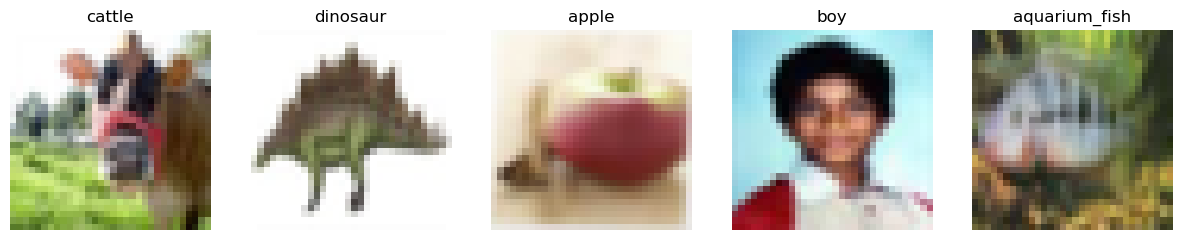

In [17]:
num_images = 5  # Número de imágenes a mostrar
fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
for i in range(num_images):
    # Seleccionamos una imagen aleatoria
    ax = axes[i]
    ax.imshow(x_train[i])  # Muestra la imagen
    ax.set_title(labelNames[y_train[i][0]])  # Muestra la etiqueta
    ax.axis('off')  # Desactiva los ejes para mejor presentación

plt.show()

In [70]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [71]:
num_classes = 100

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [72]:
def plot_sample_images(x, y, class_names, num_images=9):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(x[i])
        plt.title(class_names[int(y[i][0])])  # Accede al valor escalar correctamente
        plt.axis("off")
    plt.show()

In [73]:
class_names = ["apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
               "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
               "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
               "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
               "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
               "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
               "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose",
               "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider", "squirrel",
               "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
               "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"]

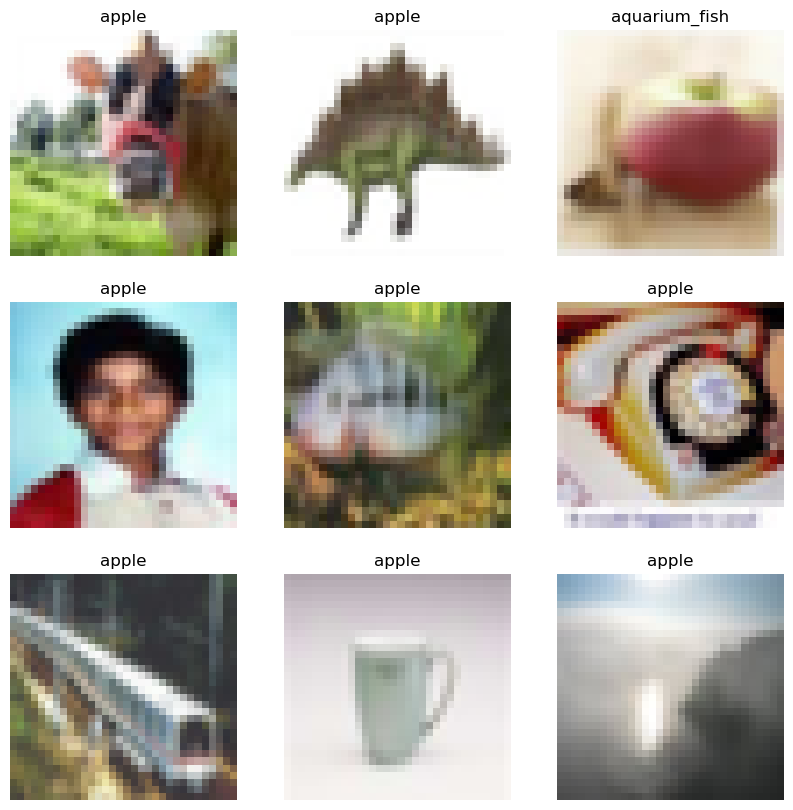

In [74]:
plot_sample_images(x_train, y_train, class_names)

In [75]:
base_model = apps.ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

In [76]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [77]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10


In [ ]:
# Evaluar el modelo
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Accuracy con ResNet50: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.0090 - loss: 4.6052
Accuracy con ResNet50: 0.0100


In [ ]:
# Entrenamiento desde cero - Red personalizada
custom_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

c:\Users\Pc\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
custom_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_custom = custom_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0389 - loss: 4.4801 - val_accuracy: 0.1088 - val_loss: 3.8725
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0849 - loss: 3.9636 - val_accuracy: 0.1219 - val_loss: 3.8039
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.1159 - loss: 3.6869 - val_accuracy: 0.1631 - val_loss: 3.4905
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.1486 - loss: 3.4918 - val_accuracy: 0.2090 - val_loss: 3.3241
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1831 - loss: 3.3046 - val_accuracy: 0.2442 - val_loss: 3.0739
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2238 - loss: 3.0958 - val_accuracy: 0.3090 - val_loss: 2.7644
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2665 - loss: 2.8933 - val_accuracy: 0.3555 - val_loss: 2.5372
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3079 - loss: 2.691

In [ ]:
# Evaluar la red desde cero
loss_custom, accuracy_custom = custom_model.evaluate(x_test, y_test)
print(f"Accuracy con la red desde cero: {accuracy_custom:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3668 - loss: 2.4975
Accuracy con la red desde cero: 0.3648


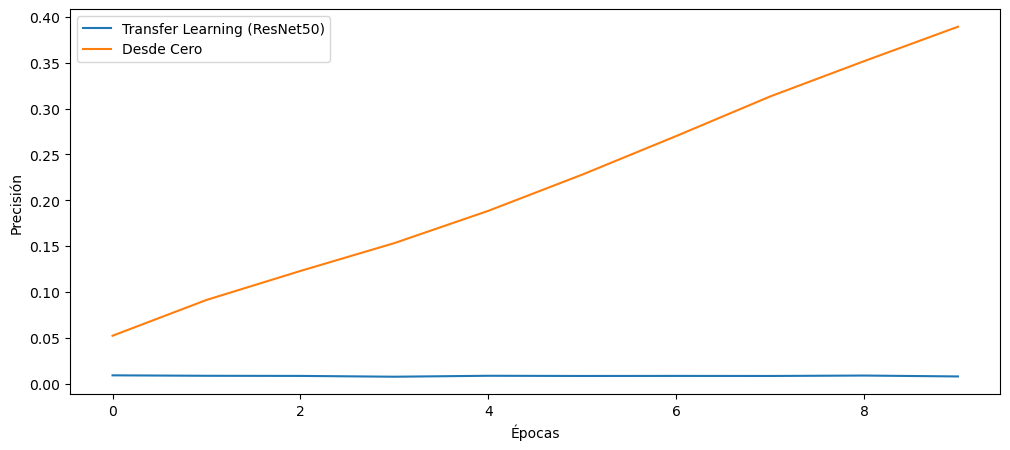

In [ ]:
# Comparación de resultados
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Transfer Learning (ResNet50)')
plt.plot(history_custom.history['accuracy'], label='Desde Cero')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


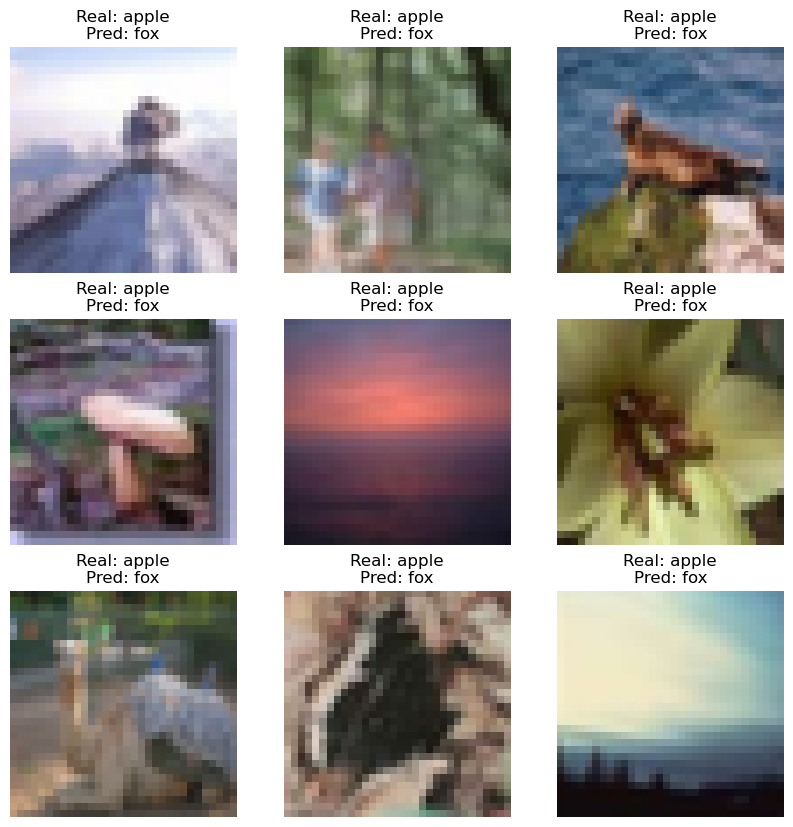

In [ ]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(x_test)

# Mostrar algunas predicciones junto con las imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    
    # Obtener las clases reales y predichas
    real_class = class_names[int(y_test[i][0])]  # Usar [0] para acceder al valor escalar
    pred_class = class_names[np.argmax(y_pred[i])]
    
    # Mostrar el título con las clases reales y predichas
    plt.title(f"Real: {real_class}\nPred: {pred_class}")
    plt.axis("off")
plt.show()